# Lesson 28: TensorFlow/Keras classification activity

## Activity Goal

In this activity, you will build and train a neural network using TensorFlow/Keras to predict room occupancy based on environmental sensor data. The activity will guide you through data preparation, creating a logistic regression baseline for comparison, and then building a neural network using Keras' Sequential API to see how deep learning performs on this binary classification task.

## Notebook set up

### Imports

In [254]:
# Third party imports
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow import keras
from tensorflow.keras import layers

## 1. Data preparation

### 1.1. Load occupancy data

In [274]:
df_occupancy = pd.read_csv('https://gperdrizet.github.io/FSA_devops/assets/data/unit4/occupancy_data.csv')
df_occupancy.head()
print(df_occupancy.shape)

(20560, 7)


In [275]:
df_occupancy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20560 entries, 0 to 20559
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           20560 non-null  object 
 1   Temperature    20560 non-null  float64
 2   Humidity       20560 non-null  float64
 3   Light          20560 non-null  float64
 4   CO2            20560 non-null  float64
 5   HumidityRatio  20560 non-null  float64
 6   Occupancy      20560 non-null  int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 1.1+ MB


In [276]:
label = 'Occupancy'
features = ['Temperature','Humidity','Light','CO2','HumidityRatio']

### 1.2. Train test split

Split the data into training and testing sets. Remember to set a random state for reproducibility.

In [277]:
# Split the data
df_training, df_testing = train_test_split(df_occupancy,random_state=42)

### 1.3. Standard scale

Scale the features to improve model performance. Consider which data should be used for fitting the scaler.

In [278]:
# Scale the features
scaler = StandardScaler()
scaler.fit(df_training[features])

df_training[features] = scaler.transform(df_training[features])
df_testing[features] = scaler.transform(df_testing[features])


## 2. Logistic regression baseline

Create a baseline model to compare against the neural network.

### 2.1. Fit

In [279]:
# Create and fit the model

model = LogisticRegression(n_jobs=-1)
fit_result = model.fit(df_training[features], df_training[label])

### 2.2. Test set evaluation

In [280]:
# Evaluate on test set
logistic_predictions = model.predict(df_testing[features])
logistic_rsquared = model.score(df_testing[features], df_testing[label])
print(f'Linear regression R² on test set: {logistic_rsquared:.4f}')


Linear regression R² on test set: 0.9901


## 3. Keras Sequential API model

The Sequential API is the simplest way to build a neural network in Keras. It allows you to create models layer-by-layer in a linear stack.

### 3.1. Build model

Build a sequential neural network with an appropriate architecture for binary classification. Consider:
- What input shape is needed based on the number of features
- How many hidden layers and neurons per layer
- What activation functions to use
- The output layer configuration for binary classification
- The optimizer, loss function, and metrics for compilation

In [281]:
# Build and compile the model

sequential_model = keras.Sequential([
                                        layers.Input(shape=(5,)),
                                        layers.Dense(32, activation='relu'),
                                        layers.Dropout(0.2),
                                        layers.Dense(16, activation='relu'),
                                        layers.Dropout(0.2),
                                        layers.Dense(1, activation='sigmoid')
                                    ])


sequential_model.compile(
                            optimizer=keras.optimizers.Adam(learning_rate=5e-4),
                            loss='binary_crossentropy',
                            metrics=['accuracy']
                        )

sequential_model.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_36 (Dense)                │ (None, 32)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 737 (2.88 KB)

 Trainable params: 737 (2.88 KB)

 Non-trainable params: 0 (0.00 B)

### 3.2. Train model

Train the model on your prepared data. You'll need to specify the number of epochs, batch size, and validation strategy.

In [ ]:
# Train the model and review final metrics
sequential_history = sequential_model.fit(
                                            df_training[features],
                                            df_training[label],
                                            epochs=250,
                                            batch_size=32,
                                            validation_split=0.2,
                                            verbose=1
                                        )

print('Training complete.')
print(f'Final training loss: {sequential_history.history["loss"][-1]:.4f}')
print(f'Final validation loss: {sequential_history.history["val_loss"][-1]:.4f}')

Epoch 1/250
771/771 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9369 - loss: 0.2213 - val_accuracy: 0.9838 - val_loss: 0.0544
Epoch 2/250
771/771 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9857 - loss: 0.0651 - val_accuracy: 0.9867 - val_loss: 0.0447
Epoch 3/250
771/771 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9878 - loss: 0.0569 - val_accuracy: 0.9890 - val_loss: 0.0426
Epoch 4/250
771/771 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9874 - loss: 0.0541 - val_accuracy: 0.9890 - val_loss: 0.0422
Epoch 5/250
771/771 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9879 - loss: 0.0500 - val_accuracy: 0.9890 - val_loss: 0.0417
Epoch 6/250
771/771 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9880 - loss: 0.0510 - val_accuracy: 0.9890 - val_loss: 0.0413
Epoch 7/250
771/771 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9885 - loss: 0.0475 - val_accuracy: 0.9877 - val_loss: 0.0420
Epoch 8/250
771/771 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9883 - loss: 0.0482 - val_accu

### 3.3. Learning curves

Visualize how the model's loss and accuracy changed during training.

{'accuracy': [0.9368515014648438, 0.9856517314910889, 0.9877594113349915, 0.9874351620674133, 0.9879215359687805, 0.988002598285675, 0.9884889721870422, 0.9883268475532532, 0.9879215359687805, 0.9880836606025696, 0.987840473651886, 0.9882457852363586, 0.9882457852363586, 0.9883268475532532, 0.9885700345039368, 0.9884079098701477, 0.9884079098701477, 0.9885700345039368, 0.9882457852363586, 0.9886510968208313, 0.9883268475532532, 0.9883268475532532, 0.9884079098701477, 0.9884889721870422, 0.9884079098701477, 0.9888132214546204, 0.9886510968208313, 0.9888942837715149, 0.9889753460884094, 0.9888942837715149, 0.9887321591377258, 0.9884889721870422, 0.9888942837715149, 0.9887321591377258, 0.9884889721870422, 0.9889753460884094, 0.9888132214546204, 0.9887321591377258, 0.9888132214546204, 0.9888132214546204, 0.9888132214546204, 0.9887321591377258, 0.9889753460884094, 0.9886510968208313, 0.9886510968208313, 0.9887321591377258, 0.9891374707221985, 0.989056408405304, 0.9888132214546204, 0.9888132

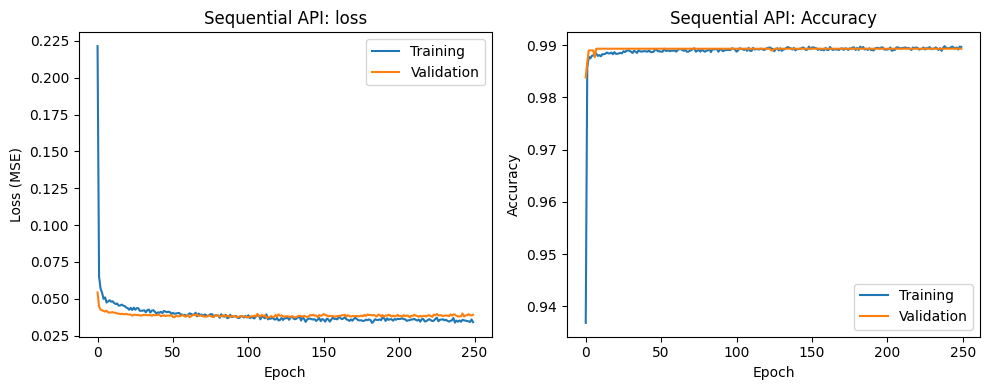

In [283]:
# Plot learning curves

print(sequential_history.history)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].set_title('Sequential API: loss')
axes[0].plot(sequential_history.history['loss'], label='Training')
axes[0].plot(sequential_history.history['val_loss'], label='Validation')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (MSE)')
axes[0].legend(loc='best')

axes[1].set_title('Sequential API: Accuracy')
axes[1].plot(sequential_history.history['accuracy'], label='Training')
axes[1].plot(sequential_history.history['val_accuracy'], label='Validation')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend(loc='best')

plt.tight_layout()
plt.show()

### 3.4. Test set evaluation

Evaluate your neural network on the test set. Remember that the model outputs probabilities that need to be converted to class predictions.

In [284]:
# Make predictions and calculate accuracy
sequential_predictions = sequential_model.predict(df_testing[features], verbose=1).flatten()

ss_res = np.sum((df_testing[label] - sequential_predictions) ** 2)
ss_tot = np.sum((df_testing[label] - np.mean(df_testing[label])) ** 2)
sequential_rsquared = 1 - (ss_res / ss_tot)

print(f'Sequential API model R² on test set: {sequential_rsquared:.4f}')

161/161 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Sequential API model R² on test set: 0.9554


### 3.5. Performance analysis

Create a confusion matrix to better understand model performance on different classes.

[9.8427683e-01 4.7105803e-25 1.0302683e-23 ... 1.8520579e-25 1.3592822e-16
 2.7337217e-13]


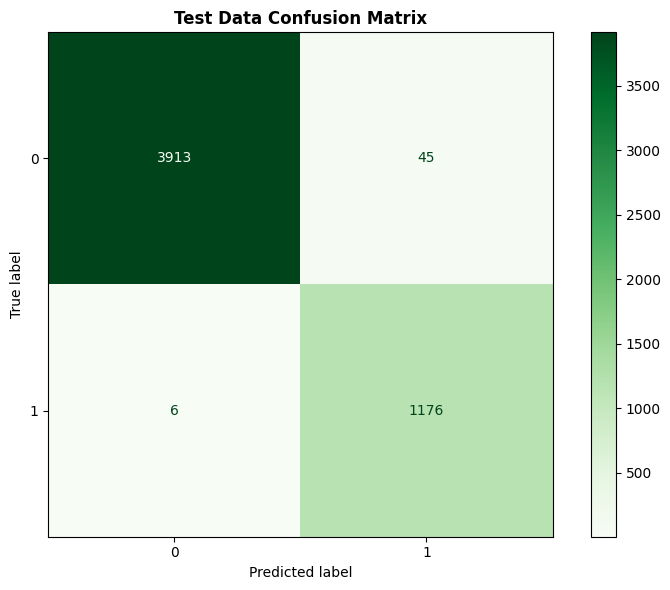

In [285]:
# Display confusion matrix

print(sequential_predictions)
sequential_predictions_binary = (sequential_predictions > 0.5).astype(int)

# Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(df_testing[label], sequential_predictions_binary, ax=ax, cmap='Greens')
plt.title('Test Data Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.show()
print()

## 4. Model comparison

Compare the performance of your logistic regression baseline with the neural network.

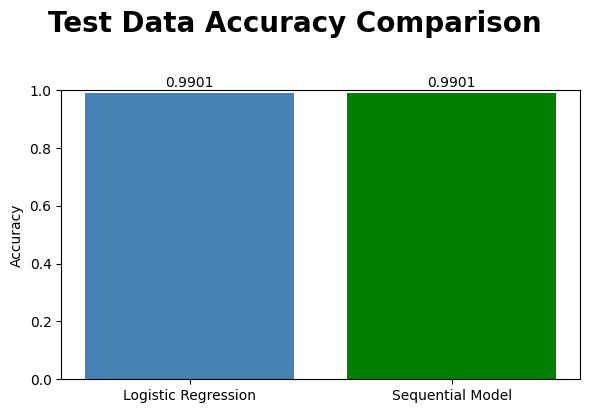

In [286]:
# Compare model accuracies


# Get the accuracy scores
logistic_regression_accuracy = accuracy_score(df_testing[label], logistic_predictions)
sequential_accuracy = accuracy_score(df_testing[label], sequential_predictions_binary)

# Plot comparison
fig, ax = plt.subplots(figsize=(6, 4))
models = ['Logistic Regression', 'Sequential Model']
accuracies = [logistic_regression_accuracy, sequential_accuracy]

ax.bar(models, accuracies, color=['steelblue', 'green'])
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1)

for i, acc in enumerate(accuracies):
    ax.text(i, acc + 0.02, f'{acc:.4f}', ha='center')

plt.suptitle('Test Data Accuracy Comparison', y=1.02, fontsize=20, fontweight='bold')
plt.subplots_adjust(top=0.92)  

plt.tight_layout()
plt.show()
print()

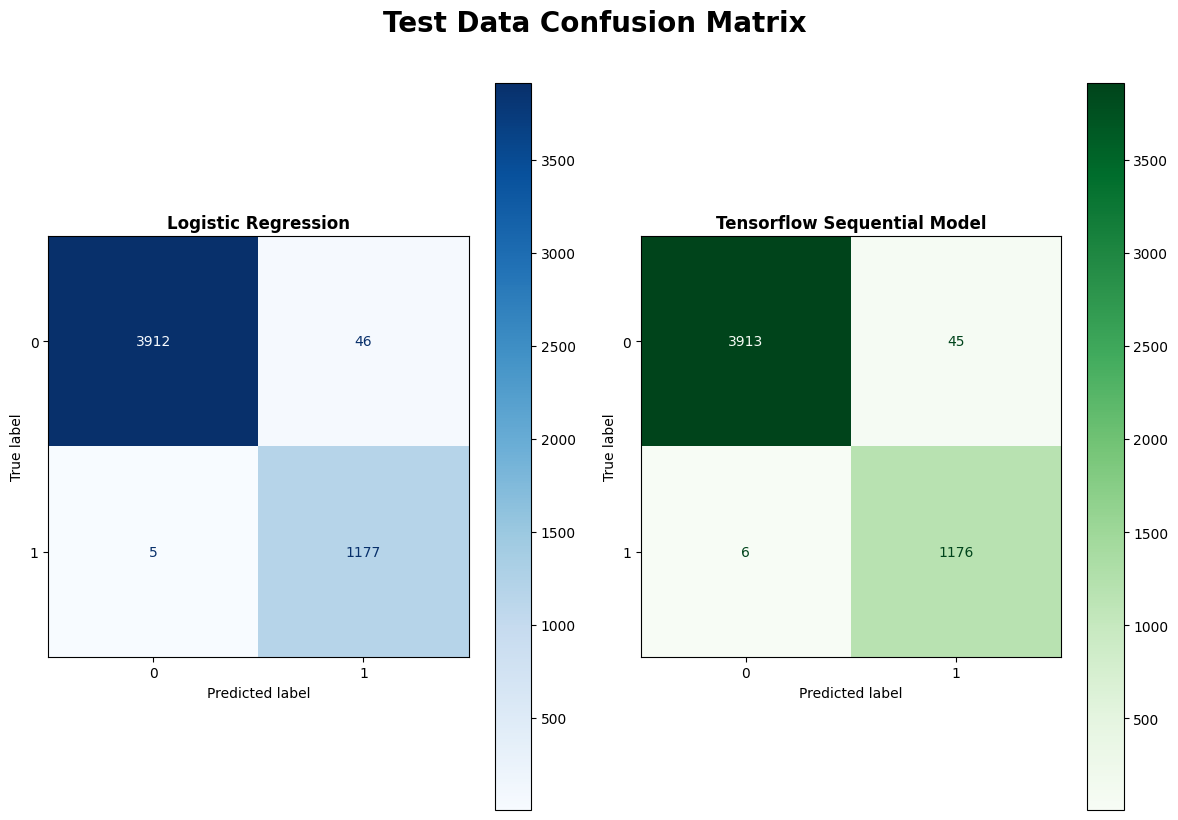

In [287]:
# Create side-by-side confusion matrix visualization

# I need a 2 column plot
fig, axes = plt.subplots(1, 2, figsize=(12, 8))
axes = axes.flatten()

ConfusionMatrixDisplay.from_predictions(df_testing[label], logistic_predictions, ax=axes[0], cmap='Blues')
axes[0].set_title('Logistic Regression', fontweight='bold')

ConfusionMatrixDisplay.from_predictions(df_testing[label], sequential_predictions_binary, ax=axes[1], cmap='Greens')
axes[1].set_title('Tensorflow Sequential Model', fontweight='bold')


plt.suptitle('Test Data Confusion Matrix', y=1.02, fontsize=20, fontweight='bold')
plt.subplots_adjust(top=0.92)  
plt.tight_layout()
plt.show()
print()